In [57]:
#%pip install pandas
#%pip install scikit-learn
#%pip install lightgbm
#%pip install xgboost
%pip install matplotlib
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --------------------- ------------------ 4.5/8.2 MB 23.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 19.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.8 MB/s  0:00:00

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
 

In [58]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import lightgbm as lgb
import xgboost as xgb
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
train = pd.read_csv('application_train.csv')
test = pd.read_csv('application_test.csv')

# Reemplazar valor centinela por nulos (Mencionado en el informe)
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)
test['DAYS_EMPLOYED'] = test['DAYS_EMPLOYED'].replace(365243, np.nan)

print(f'Tamaño del entrenamiento: {train.shape}')
print(f'Tamaño del testeo: {test.shape}')

Tamaño del entrenamiento: (307511, 122)
Tamaño del testeo: (48744, 121)


In [38]:
def unir_y_limpiar_nulos(train, test, umbral_obs=0.5, umbral_attr=0.6):
    # ==========================================
    # 1. UNIÓN DE LOS CONJUNTOS
    # ==========================================
    train_copy = train.copy()
    test_copy = test.copy()
    
    # Etiquetamos el conjunto test con TARGET = 2
    test_copy['TARGET'] = 2
    
    # Unimos ambos DataFrames
    df_unido = pd.concat([train_copy, test_copy], axis=0, ignore_index=True)
    X_resultado = df_unido.copy()
    
    print("=" * 60)
    print("🛠️ INICIANDO PROCESAMIENTO CONJUNTO")
    print("=" * 60)
    print(f"Dimensiones iniciales (unidos): {X_resultado.shape}\n")

    # ==========================================
    # 2. LIMPIEZA SECUENCIAL DE NULOS
    # ==========================================
    
    # --- PASO 1: Observaciones (Filas) ---
    predictoras = X_resultado.drop(columns=['TARGET']) # Aislamos para no contar TARGET
    n_obs, n_attr = predictoras.shape
    obs_muchos_vacios = (predictoras.isnull().sum(axis=1) / n_attr) >= umbral_obs
    cant_obs = obs_muchos_vacios.sum()
    pct_obs = (cant_obs / n_obs) * 100
    
    print(f"Observaciones con >= {umbral_obs*100:.0f}% de vacíos: {cant_obs} ({pct_obs:.2f}% del total)")
    if cant_obs > 0:
        if input("¿Deseas eliminarlas? (s/n): ").strip().lower() in ['s', 'si', 'y']:
            X_resultado = X_resultado.loc[~obs_muchos_vacios]
    
    # --- PASO 2: Atributos (Columnas) ---
    predictoras = X_resultado.drop(columns=['TARGET'])
    n_obs, n_attr = predictoras.shape
    attr_muchos_vacios = (predictoras.isnull().sum(axis=0) / n_obs) >= umbral_attr
    cant_attr = attr_muchos_vacios.sum()
    pct_attr = (cant_attr / n_attr) * 100
    
    print(f"\nAtributos con >= {umbral_attr*100:.0f}% de obs. vacías: {cant_attr} ({pct_attr:.2f}% del total)")
    if cant_attr > 0:
        if input("¿Deseas eliminarlos? (s/n): ").strip().lower() in ['s', 'si', 'y']:
            # Mantenemos las columnas que NO superan el umbral, más el TARGET
            cols_a_mantener = predictoras.columns[~attr_muchos_vacios].tolist() + ['TARGET']
            X_resultado = X_resultado[cols_a_mantener]

    # --- PASO 3: Observaciones con al menos 1 vacío ---
    predictoras = X_resultado.drop(columns=['TARGET'])
    n_obs, n_attr = predictoras.shape
    obs_cualquier_vacio = predictoras.isnull().any(axis=1)
    cant_cualq = obs_cualquier_vacio.sum()
    pct_cualq = (cant_cualq / n_obs) * 100
    
    print(f"\nObservaciones con al menos un vacío: {cant_cualq} ({pct_cualq:.2f}% del total)")
    if cant_cualq > 0:
        if input("¿Deseas eliminarlas? (s/n): ").strip().lower() in ['s', 'si', 'y']:
            X_resultado = X_resultado.loc[~obs_cualquier_vacio]

    # --- FINAL: Lista de atributos y Dimensiones ---
    predictoras = X_resultado.drop(columns=['TARGET'])
    lista_atributos_vacios = predictoras.columns[predictoras.isnull().any(axis=0)].tolist()
    
    print("\n" + "=" * 60)
    print("🏁 RESUMEN POST-LIMPIEZA")
    print("=" * 60)
    print("Atributos que todavía tienen nulos:")
    print(lista_atributos_vacios)
    print(f"\nDimensiones finales del dataset unificado: {X_resultado.shape}")

    return X_resultado

In [39]:
dataset_total = unir_y_limpiar_nulos(train, test)

🛠️ INICIANDO PROCESAMIENTO CONJUNTO
Dimensiones iniciales (unidos): (356255, 122)

Observaciones con >= 50% de vacíos: 14 (0.00% del total)

Atributos con >= 60% de obs. vacías: 17 (14.05% del total)

Observaciones con al menos un vacío: 318291 (89.35% del total)

🏁 RESUMEN POST-LIMPIEZA
Atributos que todavía tienen nulos:
['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'LANDAREA_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'LANDAREA_MEDI', 'LIVINGAREA_MEDI

In [40]:
# 1. Tu lista actual de atributos con nulos
lista_atributos_vacios = ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'LANDAREA_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'LANDAREA_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAREA_MEDI', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

# 2. Filtramos el DataFrame solo con estas columnas usando dataset_total
df_con_nulos = dataset_total[lista_atributos_vacios]

# 3. Separamos usando select_dtypes
cols_numericas = df_con_nulos.select_dtypes(include=['number']).columns.tolist()
cols_categoricas = df_con_nulos.select_dtypes(exclude=['number']).columns.tolist()

print("=" * 60)
print(f"📊 Variables Numéricas ({len(cols_numericas)}):")
print(cols_numericas)
print("-" * 60)
print(f"🔤 Variables Categóricas ({len(cols_categoricas)}):")
print(cols_categoricas)
print("=" * 60)

📊 Variables Numéricas (45):
['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'LANDAREA_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'LANDAREA_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_Y

In [41]:
# 1. Definimos tu lista de variables estrictamente enteras
cols_enteras = [
    'CNT_FAM_MEMBERS', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE',
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'DAYS_EMPLOYED'
]

# (Añadí 'DAYS_LAST_PHONE_CHANGE' a la lista porque los días también deben ser enteros).

# 2. Filtramos las numéricas para separar las continuas de las enteras
cols_continuas = [col for col in cols_numericas if col not in cols_enteras]

print("Iniciando imputación...")

# --- A. IMPUTACIÓN DE CATEGÓRICAS ---
imputer_cat = SimpleImputer(strategy='constant', fill_value='Desconocido')
dataset_total[cols_categoricas] = imputer_cat.fit_transform(dataset_total[cols_categoricas])
print(f"✅ {len(cols_categoricas)} variables categóricas imputadas con 'Desconocido'.")

# --- B. IMPUTACIÓN DE NUMÉRICAS CONTINUAS ---
imputer_num = SimpleImputer(strategy='median')
dataset_total[cols_continuas] = imputer_num.fit_transform(dataset_total[cols_continuas])
print(f"✅ {len(cols_continuas)} variables continuas imputadas con la mediana.")

# --- C. IMPUTACIÓN DE NUMÉRICAS ENTERAS ---
imputer_int = SimpleImputer(strategy='median')
dataset_total[cols_enteras] = imputer_int.fit_transform(dataset_total[cols_enteras])

# Forzamos a que no haya decimales y convertimos el tipo de dato a Integer nativo de Pandas
dataset_total[cols_enteras] = dataset_total[cols_enteras].round().astype('Int64')
print(f"✅ {len(cols_enteras)} variables discretas imputadas y convertidas estrictamente a enteros.")

print("\n¡Imputación completada con éxito! Ya no hay nulos en tu dataset.")

Iniciando imputación...
✅ 5 variables categóricas imputadas con 'Desconocido'.
✅ 33 variables continuas imputadas con la mediana.
✅ 13 variables discretas imputadas y convertidas estrictamente a enteros.

¡Imputación completada con éxito! Ya no hay nulos en tu dataset.


In [42]:
# Comprobar el total absoluto de nulos en todo el DataFrame
total_nulos = dataset_total.isnull().sum().sum()

print("=" * 60)
print(f"🔍 Total absoluto de valores nulos: {total_nulos}")
print("=" * 60)

🔍 Total absoluto de valores nulos: 0


In [43]:
print("Iniciando escalado de variables continuas...")

# 1. Inicializamos el escalador
scaler = RobustScaler()

# 2. Entrenamos y transformamos solo las columnas continuas
dataset_total[cols_continuas] = scaler.fit_transform(dataset_total[cols_continuas])

print(f"✅ {len(cols_continuas)} variables continuas han sido escaladas exitosamente con RobustScaler.")

Iniciando escalado de variables continuas...
✅ 33 variables continuas han sido escaladas exitosamente con RobustScaler.


In [44]:
print("Iniciando preparación de variables categóricas para LightGBM/XGBoost...")

# Convertimos todas las columnas de texto al tipo 'category' de Pandas
for col in cols_categoricas:
    dataset_total[col] = dataset_total[col].astype('category')

print(f"✅ {len(cols_categoricas)} variables convertidas a tipo 'category'.")
print(f"📊 Dimensiones del dataset (¡mucho más ligero sin OHE!): {dataset_total.shape}")

Iniciando preparación de variables categóricas para LightGBM/XGBoost...
✅ 5 variables convertidas a tipo 'category'.
📊 Dimensiones del dataset (¡mucho más ligero sin OHE!): (356241, 105)


In [45]:
print("Buscando variables de texto restantes...")

# 1. Identificamos TODAS las columnas que siguen siendo texto ('object') en el dataset unificado
columnas_texto = dataset_total.select_dtypes(include=['object']).columns.tolist()

# 2. Las convertimos al tipo 'category' que necesitan XGBoost y LightGBM
for col in columnas_texto:
    dataset_total[col] = dataset_total[col].astype('category')

print(f"✅ Se encontraron y convirtieron {len(columnas_texto)} columnas adicionales a 'category':")
print(columnas_texto)

Buscando variables de texto restantes...


C:\Users\sebas\AppData\Local\Temp\ipykernel_45156\2067215333.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = dataset_total.select_dtypes(include=['object']).columns.tolist()


✅ Se encontraron y convirtieron 10 columnas adicionales a 'category':
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


In [46]:
print("Iniciando la separación final del dataset...")

# 1. Recuperar el Train y Test originales basándonos en nuestro TARGET falso
train_limpio = dataset_total[dataset_total['TARGET'].isin([0, 1])].copy()
test_limpio = dataset_total[dataset_total['TARGET'] == 2].copy()

# 2. Separar predictores (X) de la variable objetivo (y)
X = train_limpio.drop(columns=['TARGET'])
y = train_limpio['TARGET'].astype(int) # Aseguramos que el target sea entero

# 3. Devolver el conjunto de prueba (test) a su estado original sin el TARGET
X_test_final = test_limpio.drop(columns=['TARGET'])

# 4. Crear el conjunto de Validación
# Usamos stratify=y para asegurar que la proporción de 0s y 1s se mantenga igual en ambos sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.20,      # Dejamos un 20% para validación
    random_state=42,     # Semilla para que siempre dé el mismo resultado
    stratify=y
)

print("\n" + "=" * 60)
print("🏁 SEPARACIÓN FINAL COMPLETADA")
print("=" * 60)
print(f"🔹 Entrenamiento (X_train, y_train): {X_train.shape[0]} filas")
print(f"🔸 Validación   (X_val, y_val):     {X_val.shape[0]} filas")
print(f"🚀 Prueba Final (X_test_final):      {X_test_final.shape[0]} filas")
print("-" * 60)
print(f"Total de atributos predictivos: {X_train.shape[1]}")
print("=" * 60)

Iniciando la separación final del dataset...

🏁 SEPARACIÓN FINAL COMPLETADA
🔹 Entrenamiento (X_train, y_train): 245998 filas
🔸 Validación   (X_val, y_val):     61500 filas
🚀 Prueba Final (X_test_final):      48743 filas
------------------------------------------------------------
Total de atributos predictivos: 104


In [47]:
# 1. Calcular dinámicamente el peso de las clases basado en el set de entrenamiento
# Esto garantiza precisión matemática exacta sobre tu dataset actual
num_clase_0 = sum(y_train == 0)
num_clase_1 = sum(y_train == 1)
peso_clase_positiva = num_clase_0 / num_clase_1

print(f"⚖️ Peso calculado para la clase minoritaria (1): {peso_clase_positiva:.2f}")

# ==========================================
# FUNCIÓN 1: LIGHTGBM CON BALANCEO
# ==========================================

⚖️ Peso calculado para la clase minoritaria (1): 11.39


In [52]:
def entrenar_lightgbm(X_train, y_train, X_val, y_val, learning_rate=0.05, num_leaves=31, num_boost_round=1000):
    
    # Configurar los parámetros del modelo incluyendo is_unbalance
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': learning_rate,
        'num_leaves': num_leaves,
        'n_jobs': -1,  # OpenMP activado
        'is_unbalance': True, # <--- ¡CLAVE! Activa el balanceo interno de LightGBM
        'verbose': -1
    }

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False), 
        lgb.log_evaluation(period=0)
    ]

    modelo_lgb = lgb.train(
        params,
        train_data,
        num_boost_round=num_boost_round,
        valid_sets=[train_data, val_data],
        callbacks=callbacks
    )

    y_pred_prob = modelo_lgb.predict(X_val)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred_class)
    return modelo_lgb, {'roc_auc': auc, 'f1_score': f1}, y_pred_class

In [53]:
def entrenar_xgboost(X_train, y_train, X_val, y_val, learning_rate=0.05, max_depth=6, num_boost_round=1000, scale_weight=1.0):
    
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',           
        'tree_method': 'hist',          
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'n_jobs': -1,  # OpenMP activado
        'scale_pos_weight': scale_weight, # <--- ¡CLAVE! Le pasamos el peso calculado
        'random_state': 42
    }

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

    evals = [(dtrain, 'entrenamiento'), (dval, 'validacion')]

    modelo_xgb = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    y_pred_prob = modelo_xgb.predict(dval)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred_class)
    return modelo_xgb, {'roc_auc': auc, 'f1_score': f1}, y_pred_class

In [54]:
print("\n" + "=" * 60)
print("🚀 INICIANDO ENTRENAMIENTO SIMULTÁNEO (Paralelismo de Tareas)")
print("=" * 60)
start_time = time.time()

# Lanzar ambos hilos
# Nota: A XGBoost le pasamos el peso que calculamos arriba
resultados = joblib.Parallel(n_jobs=2, backend="threading")([
    joblib.delayed(entrenar_lightgbm)(X_train, y_train, X_val, y_val),
    joblib.delayed(entrenar_xgboost)(X_train, y_train, X_val, y_val, scale_weight=peso_clase_positiva)
])

# Extraer resultados
(modelo_lgb, metricas_lgb, preds_lgb) = resultados[0]
(modelo_xgb, metricas_xgb, preds_xgb) = resultados[1]

end_time = time.time()

# --- REPORTE DE RESULTADOS ---
print(f"⏱️ TIEMPO TOTAL: {end_time - start_time:.2f} segundos")
print("=" * 60)
print(f"🏆 Resultados Finales:")
print(f"LightGBM -> ROC AUC: {metricas_lgb['roc_auc']:.4f} | F1-Score: {metricas_lgb['f1_score']:.4f}")
print(f"XGBoost  -> ROC AUC: {metricas_xgb['roc_auc']:.4f} | F1-Score: {metricas_xgb['f1_score']:.4f}")
print("=" * 60)

print("\n🔍 REPORTE DETALLADO - LightGBM:")
print("-" * 40)
print(classification_report(y_val, preds_lgb))

print("\n🔍 REPORTE DETALLADO - XGBoost:")
print("-" * 40)
print(classification_report(y_val, preds_xgb))


🚀 INICIANDO ENTRENAMIENTO SIMULTÁNEO (Paralelismo de Tareas)
⏱️ TIEMPO TOTAL: 27.96 segundos
🏆 Resultados Finales:
LightGBM -> ROC AUC: 0.7597 | F1-Score: 0.2733
XGBoost  -> ROC AUC: 0.7557 | F1-Score: 0.2787

🔍 REPORTE DETALLADO - LightGBM:
----------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56535
           1       0.17      0.66      0.27      4965

    accuracy                           0.72     61500
   macro avg       0.57      0.69      0.55     61500
weighted avg       0.90      0.72      0.78     61500


🔍 REPORTE DETALLADO - XGBoost:
----------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56535
           1       0.18      0.64      0.28      4965

    accuracy                           0.73     61500
   macro avg       0.57      0.69      0.56     61500
weighted avg       0.90      0.73      0.79 

In [55]:
print("\n" + "=" * 60)
print("🐌 INICIANDO ENTRENAMIENTO SECUENCIAL (Uno tras otro)")
print("=" * 60)
start_time_seq = time.time()

# 1. Entrenar LightGBM
print("Entrenando LightGBM...")
modelo_lgb_seq, metricas_lgb_seq, preds_lgb_seq = entrenar_lightgbm(X_train, y_train, X_val, y_val)

# 2. Entrenar XGBoost (después de que termine LightGBM)
print("\nEntrenando XGBoost...")
modelo_xgb_seq, metricas_xgb_seq, preds_xgb_seq = entrenar_xgboost(X_train, y_train, X_val, y_val, scale_weight=peso_clase_positiva)

end_time_seq = time.time()
tiempo_secuencial = end_time_seq - start_time_seq

print("=" * 60)
print(f"⏱️ TIEMPO TOTAL SECUENCIAL: {tiempo_secuencial:.2f} segundos")
print("=" * 60)

# Recuperar el tiempo de la ejecución paralela anterior
# Asegúrate de que la variable 'start_time' y 'end_time' de la celda paralela
# sigan existiendo en memoria. Si las llamaste igual, el tiempo fue:
tiempo_paralelo = end_time - start_time

# --- TABLA COMPARATIVA ---
print("\n" + "=" * 60)
print("📊 COMPARATIVA DE TIEMPOS DE ENTRENAMIENTO (Paralelismo de Tareas)")
print("=" * 60)
print(f"{'Método':<20} | {'Tiempo (segundos)':<20} | {'Mejora (%)':<15}")
print("-" * 60)
print(f"{'Secuencial':<20} | {tiempo_secuencial:<20.2f} | Base")

# Evitar división por cero si algo falla
if tiempo_secuencial > 0:
    mejora = ((tiempo_secuencial - tiempo_paralelo) / tiempo_secuencial) * 100
    print(f"{'Paralelo (joblib)':<20} | {tiempo_paralelo:<20.2f} | {mejora:.1f}%")
else:
    print(f"{'Paralelo (joblib)':<20} | {tiempo_paralelo:<20.2f} | N/A")
print("=" * 60)


🐌 INICIANDO ENTRENAMIENTO SECUENCIAL (Uno tras otro)
Entrenando LightGBM...

Entrenando XGBoost...
⏱️ TIEMPO TOTAL SECUENCIAL: 35.93 segundos

📊 COMPARATIVA DE TIEMPOS DE ENTRENAMIENTO (Paralelismo de Tareas)
Método               | Tiempo (segundos)    | Mejora (%)     
------------------------------------------------------------
Secuencial           | 35.93                | Base
Paralelo (joblib)    | 27.96                | 22.2%


Generando gráfico comparativo...


C:\Users\sebas\AppData\Local\Temp\ipykernel_45156\4087282826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metodos, y=tiempos, palette=colores)
C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


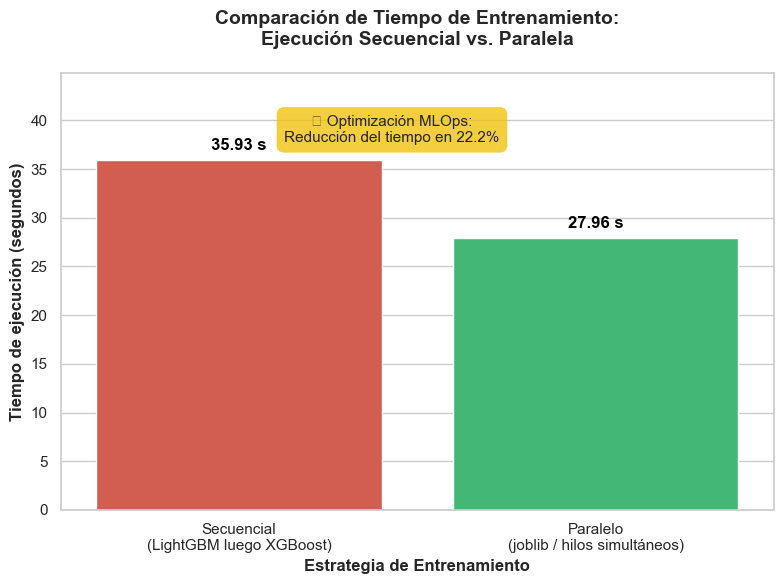

In [59]:
print("Generando gráfico comparativo...")

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Datos para el gráfico
metodos = ['Secuencial\n(LightGBM luego XGBoost)', 'Paralelo\n(joblib / hilos simultáneos)']
tiempos = [tiempo_secuencial, tiempo_paralelo]

# Crear el gráfico de barras
colores = ['#e74c3c', '#2ecc71'] # Rojo para el lento, Verde para el rápido
ax = sns.barplot(x=metodos, y=tiempos, palette=colores)

# Personalizar títulos y etiquetas
plt.title('Comparación de Tiempo de Entrenamiento:\nEjecución Secuencial vs. Paralela', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=12, fontweight='bold')
plt.xlabel('Estrategia de Entrenamiento', fontsize=12, fontweight='bold')

# Añadir los valores exactos sobre cada barra
for i, v in enumerate(tiempos):
    ax.text(i, v + (max(tiempos) * 0.02), f"{v:.2f} s", ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Añadir una etiqueta flotante con el porcentaje de mejora
if tiempo_secuencial > 0:
    mejora = ((tiempo_secuencial - tiempo_paralelo) / tiempo_secuencial) * 100
    texto_mejora = f"🔥 Optimización MLOps:\nReducción del tiempo en {mejora:.1f}%"
    plt.figtext(0.5, 0.75, texto_mejora, ha="center", fontsize=11, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f1c40f", edgecolor="none", alpha=0.8))

# Ajustar el límite Y para que la etiqueta no se corte
plt.ylim(0, max(tiempos) * 1.25)
plt.tight_layout()

# Mostrar el gráfico
plt.show()